In [1]:
import json
import pandas as pd
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(
    context="paper",
    style="ticks",
    palette="Set2",
    rc={
        "figure.dpi": 600, "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "figure.labelsize": "small",
    },
)

import numpy as np
from scipy import stats
import statsmodels.stats.power as smp
from scipy.stats import ttest_1samp

In [2]:
# Load all JSON files
results_dir = Path("/data/zchen160/cache/bonner-caching/temporal_dimensionality/behavior/image_matching_experiment/v02_init_extra_resolve_subject_return/data/responses_cleaned")
all_results = []
for json_file in results_dir.glob("*.json"):
    with open(json_file, 'r') as f:
        data = json.load(f)
        all_results.append(data)
len(all_results)

50

In [3]:
# Convert to DataFrame
responses_list = []
for result in all_results:
    participant_info = {
        'prolific_pid': result.get('prolific_pid'),
        'participant_number': result.get('participant_number'),
    }
    
    for response in result.get('responses', []):
        response_data = {**participant_info, **response}
        responses_list.append(response_data)

df_all = pd.DataFrame(responses_list)

# 1. Practice accuracy (example trials)
print("PRACTICE TRIAL ACCURACY:")
print("-" * 50)
practice_df = df_all[df_all['trial_id'] == 'example_trial']
practice_acc = practice_df.groupby('participant_number')['is_correct'].mean()
# for participant_number, acc in practice_acc.items():
    # print(f"Participant {participant_number}: {acc:.2%}")
print(f"Average: {practice_acc.mean():.2%}")

# 2. Catch trial accuracy
print("\nCATCH TRIAL ACCURACY:")
print("-" * 50)
catch_df = df_all[df_all['is_catch_trial'] == True]
catch_acc = catch_df.groupby('participant_number')['is_correct'].mean()
for participant_number, acc in catch_acc.items():
    print(f"Participant {participant_number}: {acc:.2%}")
print(f"Average: {catch_acc.mean():.2%}")

# plt.close()
# fig, ax = plt.subplots(figsize=(1, 3))
# sns.violinplot(catch_acc.values, ax=ax, fill=True, alpha=0.5)
# ax.set_ylabel("catch trial accuracy")
# sns.despine(ax=ax)

PRACTICE TRIAL ACCURACY:
--------------------------------------------------
Average: 100.00%

CATCH TRIAL ACCURACY:
--------------------------------------------------
Participant -1: 100.00%
Participant 1: 100.00%
Participant 2: 40.00%
Participant 3: 60.00%
Participant 4: 100.00%
Participant 5: 100.00%
Participant 6: 100.00%
Participant 7: 100.00%
Participant 8: 100.00%
Participant 9: 100.00%
Participant 10: 100.00%
Participant 11: 100.00%
Participant 12: 100.00%
Participant 13: 100.00%
Participant 14: 100.00%
Participant 15: 80.00%
Participant 16: 100.00%
Participant 17: 80.00%
Participant 18: 100.00%
Participant 19: 100.00%
Participant 20: 100.00%
Participant 21: 100.00%
Participant 22: 100.00%
Participant 23: 100.00%
Participant 24: 100.00%
Participant 25: 100.00%
Participant 26: 100.00%
Participant 27: 100.00%
Participant 28: 100.00%
Participant 29: 100.00%
Participant 30: 100.00%
Participant 31: 100.00%
Participant 32: 100.00%
Participant 33: 100.00%
Participant 34: 100.00%
Partic

In [4]:
# 3. Filter to only actual experiment trials (non-practice, non-catch)
df = df_all[(df_all['trial_id'] != 'example_trial') & (df_all['is_catch_trial'] != True)]

# 4. Experiment trial accuracy
print("\nEXPERIMENT TRIAL ACCURACY:")
print("-" * 50)
exp_acc = df.groupby('participant_number')['is_correct'].mean()
# for participant_number, acc in exp_acc.items():
#     print(f"Participant {participant_number}: {acc:.2%}")
print(f"Average: {exp_acc.mean():.2%}")


EXPERIMENT TRIAL ACCURACY:
--------------------------------------------------
Average: 62.22%


In [5]:
exp_acc.std()

0.059049961551077015

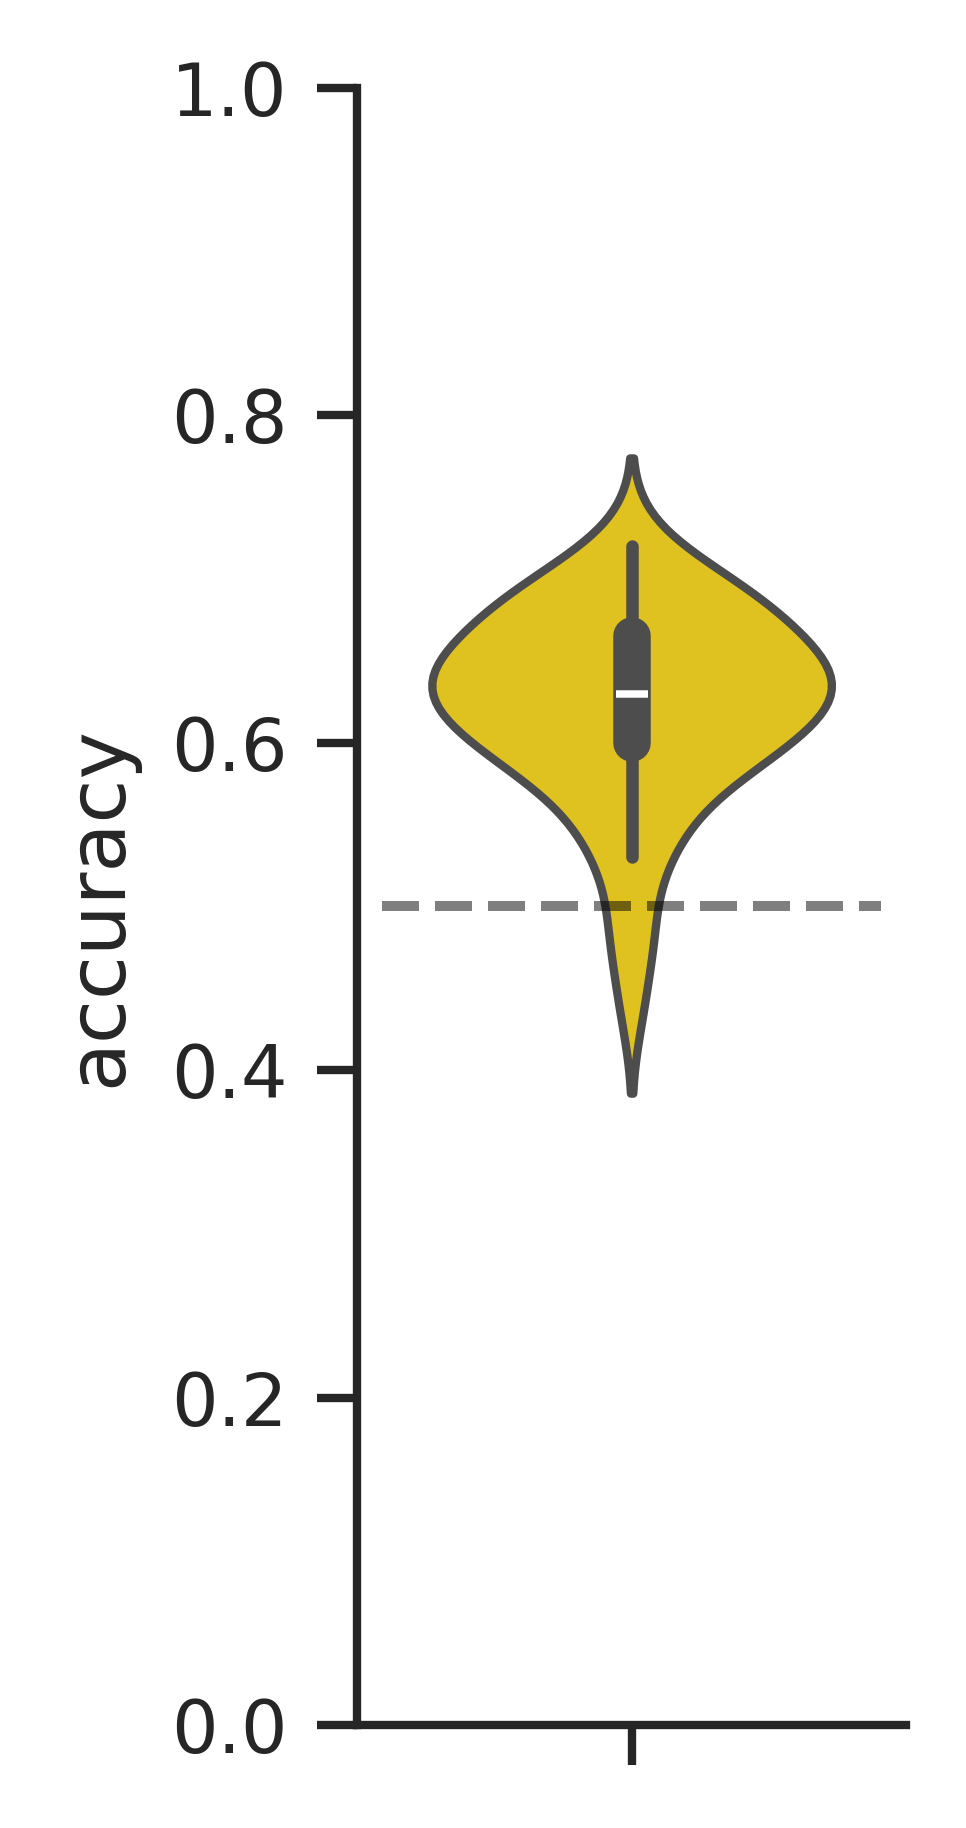

In [6]:
plt.close()
width_mm = 180
width_inches = width_mm / 25.4 / 6
height_inches = width_inches * 3
fig, ax = plt.subplots(figsize=(width_inches, height_inches))
sns.violinplot(exp_acc.values, ax=ax, fill=True, color="gold")
ax.set_ylabel("accuracy")
ax.set(ylim=(0, 1))
ax.hlines(0.5, *ax.get_xlim(), linestyles='dashed', colors='black', alpha=0.5)
sns.despine(ax=ax)

In [7]:
exp_acc = exp_acc.values
n = len(exp_acc)
t_stat, p_value = stats.ttest_1samp(exp_acc, 0.5, alternative='greater')
t_stat, p_value, n

(14.63310836980895, 8.168297082042811e-20, 50)

In [8]:
mean_acc = exp_acc.mean()
std_acc = np.std(exp_acc, ddof=1)
cohen_d = (mean_acc - 0.5) / std_acc
cohen_d

2.0694340316259066